In [9]:
from engine.optimizer import CMAESGameOptimizer
from engine.statistics import load_experiment_stats



In [22]:
# The session_id was generated during initialization
session_id = 'f307d126'

# We can load the exact dict saved to disk
saved_data = CMAESGameOptimizer.load_results(session_id, out_dir='../outputs')

In [23]:
saved_data

{'payoffs': [tensor([[ 0.2665, -0.0181],
          [ 0.3075, -0.2126]], dtype=torch.float64),
  tensor([[-0.0978, -0.2683],
          [-0.4620,  0.6422]], dtype=torch.float64)],
 'regret': np.float64(6.385823784290551),
 'config': {'name': 'random_omwu',
  'session_id': 'f307d126',
  'parent_session_id': None,
  'game': {'num_players': 2,
   'action_sizes': [2, 2],
   'utility_range': (-1.0, 1.0),
   'generator': 'random',
   'payoffs': None,
   'seed': 42},
  'dynamic': {'algorithm': 'omwu',
   'eta': None,
   'dmwu_gamma': 0.1,
   'strict_theory_eta': False,
   'initial_strategy_type': 'uniform',
   'custom_initial_strategies': None,
   'logit_penalty_threshold': 12.0,
   'logit_penalty_norm': 2,
   'logit_penalty_mode': 'centered'},
  'checkpoint': {'enabled': True,
   'checkpoint_dir': 'checkpoints',
   'save_interval': 1000,
   'keep_top_k': 5},
  'logging': {'log_level': 'INFO',
   'log_interval': 500,
   'save_stats_interval': 100,
   'sample_interval': 1,
   'output_dir': 'outp

In [26]:
from engine.statistics import unpack_stats

# Load and unpack the recorded statistics from disk
stats_data = load_experiment_stats(output_dir='../outputs', session_id='reprod_3b41094f_d33a')
steps, cum_regrets, strats, logits, instant_payoffs = unpack_stats(stats_data)

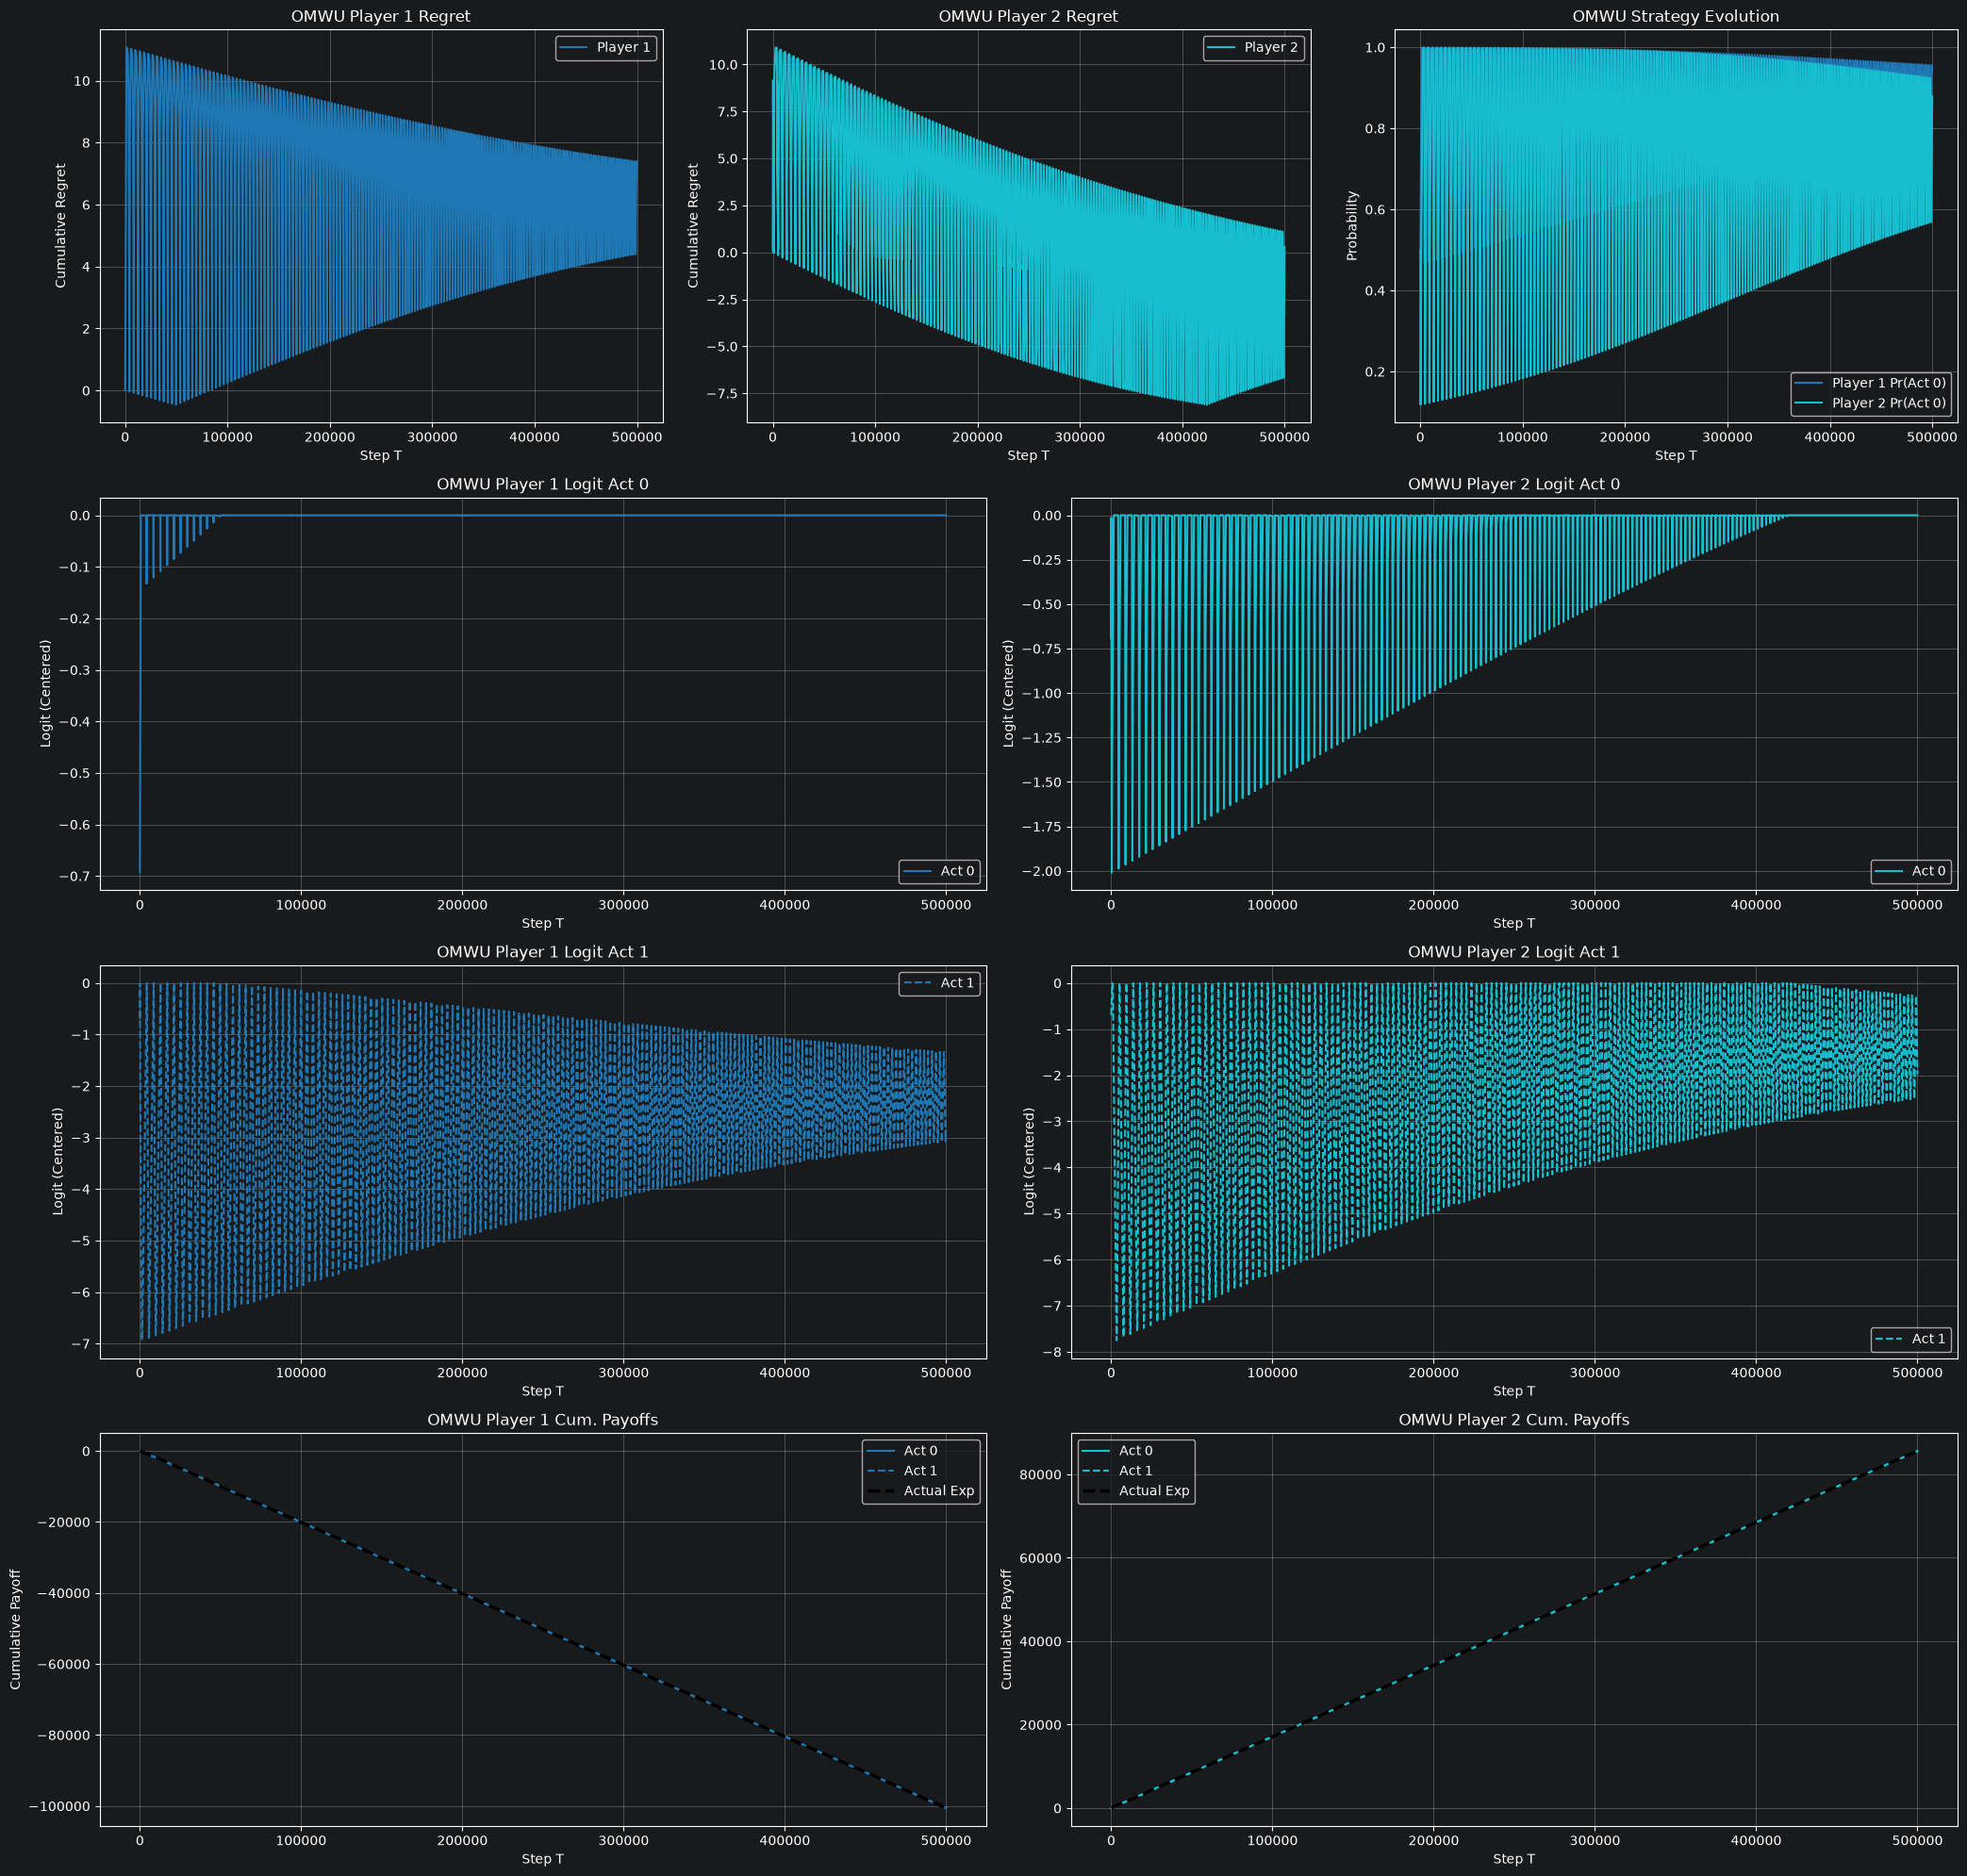

In [27]:
from matplotlib import pyplot as plt
from utils.visualization import plot_static_trajectories
import torch

cum_action_payoffs = [torch.cumsum(p, dim=0) for p in instant_payoffs]
cum_expected_payoffs = [torch.cumsum(torch.sum(s * p, dim=-1), dim=0) for s, p in zip(strats, instant_payoffs)]
fig, axes = plot_static_trajectories(steps, cum_regrets, strats, title_prefix="OMWU", plot_all_actions=False, start_step=0, end_step=600000, separate_regret_plots=True, cum_action_payoffs=cum_action_payoffs, cum_expected_payoffs=cum_expected_payoffs, logits=logits, plot_logits=True, separate_logit_plots=True)
plt.show()